# NEWTON’S AND QUASI-NEWTON’S METHODS

## Newtons method

$$f(x) = 100*(x_2-x_1^2)^2 + (1-x_1)^2 $$

The only minimum is at $$ x = (1,1)^T $$ where $$ f(1,1) = 0 $$

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
def calculate_objective(x):
    x1, x2 = x
    return 100*(x2-(x1)**2)**2 + (1-x1)**2

def compute_gradient(x):
    x1, x2 = x
    df_dx1 = -400*x1*(x2-x1**2) - 2*(1-x1)
    df_dx2 = 200*(x2-x1**2)
    return np.array([df_dx1, df_dx2])

def compute_hessian(x):
    x1, x2 = x
    df_dx1_dx1 = -400*x2+1200*x1**2 + 2
    df_dx2_dx2 = 200
    df_dx2_dx1 = -400*x1
    return np.array([[df_dx1_dx1, df_dx2_dx1],
                    [df_dx2_dx1, df_dx2_dx2]])

def newton(x_0, epsilon = 1e-6, iterations = 1000):
    x = x_0
    positions = []
    gradients = []
    hessians = []
    func_values = []
    epsilons = []

    start_time = time.time()
    for iteration in range(iterations):
        positions.append(x)
        gradient = compute_gradient(x)
        gradients.append(gradient)
        hessian = compute_hessian(x)
        hessians.append(hessian)
        func_values.append(calculate_objective(x))
        if iteration > 0:
            epsilons.append(np.linalg.norm(positions[-1] - positions[-2]))
        if np.linalg.norm(gradient) < epsilon:
            print(f"Coincided in {iteration} iterations")
            break

        d = np.linalg.solve(hessian, -gradient)
        x = x + d

    running_time = time.time() - start_time

    return x, func_values, epsilons, positions, gradients, hessians, running_time

Coincided in 2 iterations
x_0 = [2. 4.]

Running time = 0.0
Results = [1. 1.]

func_values: [np.float64(1.0), np.float64(100.00000000003703), np.float64(8.491348087605547e-27)], 

epsilons: [np.float64(4.1231056256180425), np.float64(1.000000000000186)], 

positions: [array([2., 4.]), array([ 1.00000000e+00, -3.70370401e-13]), array([1., 1.])], 

gradients: [array([2., 0.]), array([ 400., -200.]), array([-1.84297022e-13,  0.00000000e+00])], 

hessians: [array([[3202., -800.],
       [-800.,  200.]]), array([[1202., -400.],
       [-400.,  200.]]), array([[ 802., -400.],
       [-400.,  200.]])]
Coincided in 5 iterations
x_0 = [-2. 10.]

Running time = 0.0
Results = [1. 1.]

func_values: [np.float64(3609.0), np.float64(9.015018774774354), np.float64(8086.4803571339025), np.float64(1.4082028744364489e-05), np.float64(1.983035328645723e-08), np.float64(8.61460760404633e-29)], 

epsilons: [np.float64(5.989992182290567), np.float64(12.378704911083444), np.float64(8.992490100113823), np.floa

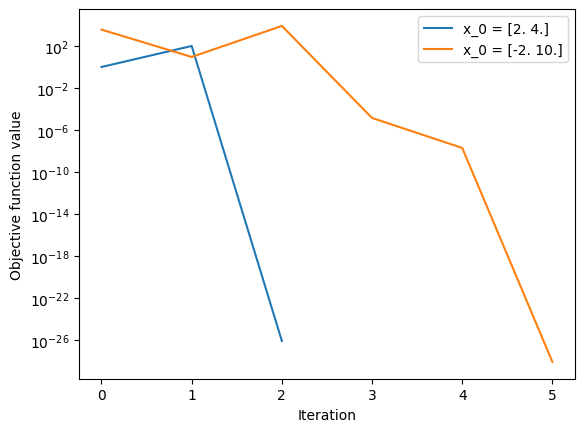

In [4]:
x_0_1 = np.array([2.0, 4.0])
x_0_2 = np.array([-2.0, 10.0])
x_0s = [x_0_1, x_0_2]
plt.figure()
for i, x_0 in enumerate(x_0s):
    x, func_values, epsilons, positions, gradients, hessians, running_time = newton(x_0)
    print(f"x_0 = {x_0}\n\nRunning time = {running_time}\nResults = {x}\n")
    print(f"func_values: {func_values}, \n\nepsilons: {epsilons}, \n\npositions: {positions}, \n\ngradients: {gradients}, \n\nhessians: {hessians}")
    plt.plot(func_values, label=f"x_0 = {x_0}")

plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Objective function value")
plt.legend()
plt.show()

Coincided in 2 iterations
Coincided in 5 iterations


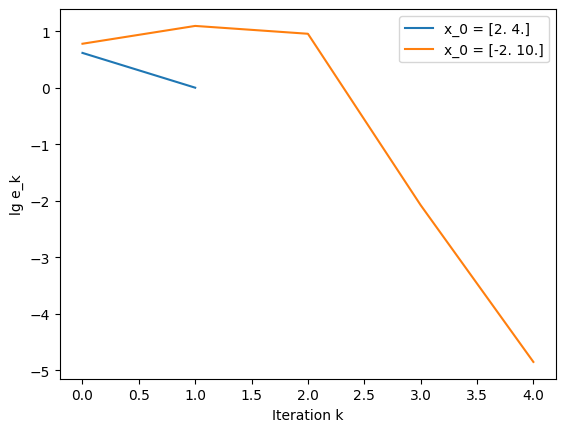

In [5]:
plt.figure()
for i, x_0 in enumerate(x_0s):
    x, func_values, epsilons, positions, gradients, hessians, running_time = newton(x_0)
    lg_epsilons = np.log10(epsilons)
    plt.plot(lg_epsilons, label=f"x_0 = {x_0}")

plt.xlabel("Iteration k")
plt.ylabel("lg e_k")
plt.legend()
plt.show()

## BFGS algorithm (Broyden – Fletcher – Goldfarb - Shanno algorithm

In [28]:
def quasi_newton(x_0, epsilon = 1e-6, iterations = 1000):
    x = x_0.copy()
    n = len(x)
    H = np.eye(n)

    positions = []
    hessian_dif = []
    func_values = []
    epsilons = []

    start_time = time.time()
    for iteration in range(iterations):

        positions.append(x)

        gradient = compute_gradient(x)

        hessian = compute_hessian(x)

        func_values.append(calculate_objective(x))

        H_inv = np.linalg.inv(hessian)
        diff = np.linalg.norm(H_inv - H)
        print(f"Norm of difference: {diff}")
        hessian_dif.append(diff)

        if iteration > 0:
            epsilons.append(np.linalg.norm(positions[-1] - positions[-2]))

        if (iteration > 0) and (abs(func_values[-1] - func_values[-2]) < epsilon):
            print(f"Coincided in {iteration} iterations")
            break

        d = -H@gradient
        x_k1 = x + d

        gradient_k1 = compute_gradient(x_k1)

        dx = d
        dg = gradient_k1 - gradient

        dg_dx = dg @ dx

        H_dg = H @ dg

        if abs(dg_dx) > 1e-14:
            H = H + (1 + (dg @ H_dg)/dg_dx)*(np.outer(dx,dx)/dg_dx) - (np.outer(H_dg,dx) + np.outer(dx, H_dg))/dg_dx

        x = x_k1
    running_time = time.time() - start_time

    return x, func_values, epsilons, positions, hessian_dif, running_time

Norm of difference: 7.5709989433371225
Norm of difference: 40001.500613142365
Norm of difference: 0.014987498913508231
Norm of difference: 0.014987485278796876
Norm of difference: 0.015012165062957182
Norm of difference: 0.015062842830699683
Norm of difference: 0.0152080140375491
Norm of difference: 0.015493685561946033
Norm of difference: 0.016094650740204632
Norm of difference: 0.01731095589424436
Norm of difference: 0.019922997843890438
Norm of difference: 0.02609122314792617
Norm of difference: 0.043774553327037
Norm of difference: 0.11488817322915228
Norm of difference: 0.6269520782583973
Norm of difference: 10.523275406655264
Norm of difference: 1026.5893364503163
Norm of difference: 1697767.5769707647
Norm of difference: 1146817870.9367945
Norm of difference: 1152263706.2431674
Norm of difference: 15970603.985784069
Norm of difference: 7955605.370577554
Norm of difference: 3955648.9054243416
Norm of difference: 2257403.132250546
Norm of difference: 1315371.8306683083
Norm of dif

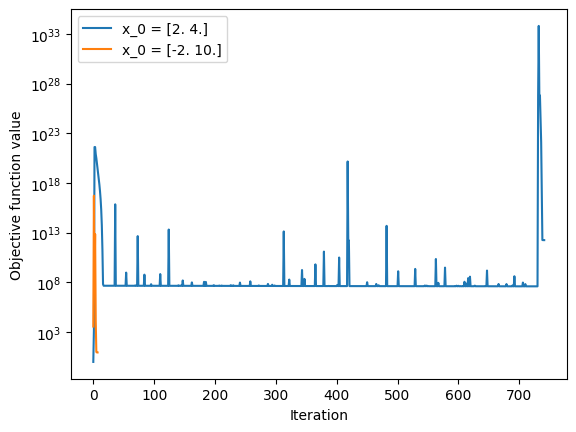

In [29]:
for i, x_0 in enumerate(x_0s):
    x, func_values, epsilons, positions, hessian_dif, running_time = quasi_newton(x_0)
    print(f"x_0 = {x_0}\n\nRunning time = {running_time}\nResults = {x}\n")
    plt.plot(func_values, label=f"x_0 = {x_0}")

plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Objective function value")
plt.legend()
plt.show()

Norm of difference: 7.5709989433371225
Norm of difference: 40001.500613142365
Norm of difference: 0.014987498913508231
Norm of difference: 0.014987485278796876
Norm of difference: 0.015012165062957182
Norm of difference: 0.015062842830699683
Norm of difference: 0.0152080140375491
Norm of difference: 0.015493685561946033
Norm of difference: 0.016094650740204632
Norm of difference: 0.01731095589424436
Norm of difference: 0.019922997843890438
Norm of difference: 0.02609122314792617
Norm of difference: 0.043774553327037
Norm of difference: 0.11488817322915228
Norm of difference: 0.6269520782583973
Norm of difference: 10.523275406655264
Norm of difference: 1026.5893364503163
Norm of difference: 1697767.5769707647
Norm of difference: 1146817870.9367945
Norm of difference: 1152263706.2431674
Norm of difference: 15970603.985784069
Norm of difference: 7955605.370577554
Norm of difference: 3955648.9054243416
Norm of difference: 2257403.132250546
Norm of difference: 1315371.8306683083
Norm of dif

C:\Users\valer\AppData\Local\Temp\ipykernel_6812\4171649791.py:4: RuntimeWarning: divide by zero encountered in log10
  lg_epsilons = np.log10(epsilons)


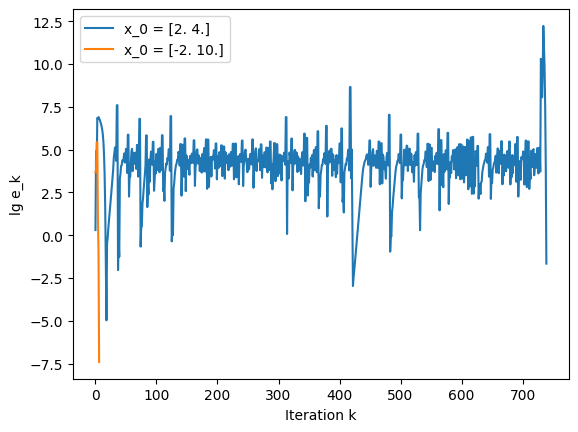

In [30]:
plt.figure()
for i, x_0 in enumerate(x_0s):
    x, func_values, epsilons, positions, hessian_dif, running_time = quasi_newton(x_0)
    lg_epsilons = np.log10(epsilons)
    plt.plot(lg_epsilons, label=f"x_0 = {x_0}")

plt.xlabel("Iteration k")
plt.ylabel("lg e_k")
plt.legend()
plt.show()

Norm of difference: 7.5709989433371225
Norm of difference: 40001.500613142365
Norm of difference: 0.014987498913508231
Norm of difference: 0.014987485278796876
Norm of difference: 0.015012165062957182
Norm of difference: 0.015062842830699683
Norm of difference: 0.0152080140375491
Norm of difference: 0.015493685561946033
Norm of difference: 0.016094650740204632
Norm of difference: 0.01731095589424436
Norm of difference: 0.019922997843890438
Norm of difference: 0.02609122314792617
Norm of difference: 0.043774553327037
Norm of difference: 0.11488817322915228
Norm of difference: 0.6269520782583973
Norm of difference: 10.523275406655264
Norm of difference: 1026.5893364503163
Norm of difference: 1697767.5769707647
Norm of difference: 1146817870.9367945
Norm of difference: 1152263706.2431674
Norm of difference: 15970603.985784069
Norm of difference: 7955605.370577554
Norm of difference: 3955648.9054243416
Norm of difference: 2257403.132250546
Norm of difference: 1315371.8306683083
Norm of dif

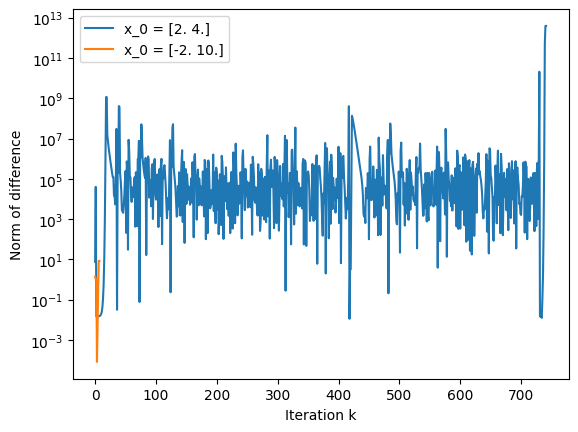

In [31]:
plt.figure()
for i, x_0 in enumerate(x_0s):
    x, func_values, epsilons, positions, hessian_dif, running_time = quasi_newton(x_0)
    plt.plot(hessian_dif, label=f"x_0 = {x_0}")

plt.xlabel("Iteration k")
plt.ylabel("Norm of difference")
plt.yscale('log')
plt.legend()
plt.show()

## How accurate is the approximation?
Графік сильно коливається, тому апроксимація нестабільна через відсутність кроку, який був взятий за 1.

Theoretical questions 2 points
1. 0.5pts What are the conditions for the stoping of the search process in the algorithms of the Newton and Quasi-Newton methods?
Якщо норма градієнта менша за задану точність е.
Якщо абсолютна різниця між значеннями функції на сусідніх ітераціях менша за е.
Якщо ми досягли ліміту ітерацій.
2. 0.5pts Under what conditions does the classical Newton method converge to a solution to the problem of unconstrained minimization with quadratic rate?
1) Початкове наближення повинно бути максимальним до точки мінімуму
2) функція f(x) має бути принаймні двічі диференційована
3) зростання функції має бути обмежене
3. 0.5pts What are the disadvantages of the classical Newton method and what approaches are used to overcome them?
1) Метод може розбігатись, якщо його початкова точка знаходиться далеко від мінімуму
 Рішення - використовувати Step-Adjusted Newton Method
2) Якщо похідна дорівнює нулю, метод не збіжний
Рішення - Quasi-Newton
3) Потрібно обчислювати обернену похідну на кожному ітераційному кроці
Рішення - Quasi-Newton
4. 0.5pts What is the main idea of Quasi-Newton methods?
Замінити матрицю Гессіана на її апроксимацію